# 03 — Évaluation, test et démonstration

Ce notebook restaure le meilleur checkpoint, mesure ses performances sur les 6 706 caractères du test indépendant, analyse la matrice de confusion et montre des prédictions réelles.

In [1]:
from pathlib import Path
import json, sys
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch

ROOT=Path('..').resolve(); sys.path.insert(0,str(ROOT))
from src.data import BalineseDataModule
from src.models.lightning_module import BalineseClassifier

data=BalineseDataModule(ROOT/'data/processed',backbone='resnet18',image_size=128,batch_size=256,num_workers=0)
data.setup()
checkpoint=next((ROOT/'models/checkpoints/resnet18-128').glob('best-*.ckpt'))
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model=BalineseClassifier.load_from_checkpoint(checkpoint,map_location=device).to(device).eval()
print('Checkpoint :',checkpoint.name)
print('Device :',device)
print('Test :',len(data.test_dataset),'images')

Checkpoint : best-epoch=01-val_loss=0.1446.ckpt
Device : cuda
Test : 6706 images


## 1. Inférence complète sur le test

Cette cellule refait les prédictions du checkpoint et calcule la matrice de confusion sans utiliser les étiquettes pour ajuster le modèle.

In [2]:
confusion=torch.zeros(data.num_classes,data.num_classes,dtype=torch.int64)
all_predictions=[]; all_labels=[]; all_confidences=[]; all_images=[]
with torch.inference_mode():
    for images,labels in data.test_dataloader():
        probabilities=model(images.to(device)).softmax(dim=1).cpu()
        predictions=probabilities.argmax(dim=1)
        confusion += torch.bincount(labels*data.num_classes+predictions,minlength=data.num_classes**2).reshape_as(confusion)
        all_predictions.extend(predictions.tolist()); all_labels.extend(labels.tolist())
        all_confidences.extend(probabilities.max(dim=1).values.tolist())
        if len(all_images)<80: all_images.extend(images[:80-len(all_images)])
print('Prédictions terminées :',len(all_predictions))

Prédictions terminées : 6706


## 2. Métriques globales et macro

Les métriques macro donnent le même poids à chaque classe, contrairement à l’accuracy qui est dominée par les classes fréquentes.

In [3]:
tp=confusion.diag().float(); support=confusion.sum(1).float(); predicted=confusion.sum(0).float()
recall=tp/support.clamp_min(1); precision=tp/predicted.clamp_min(1)
f1=2*precision*recall/(precision+recall).clamp_min(1e-12)
results={
    'Accuracy':float(tp.sum()/support.sum()),
    'Macro précision':float(precision.mean()),
    'Macro rappel':float(recall.mean()),
    'Macro F1':float(f1.mean()),
}
for name,value in results.items(): print(f'{name:>17} : {value:.2%}')

         Accuracy : 96.76%
  Macro précision : 92.74%
     Macro rappel : 93.56%
         Macro F1 : 92.91%


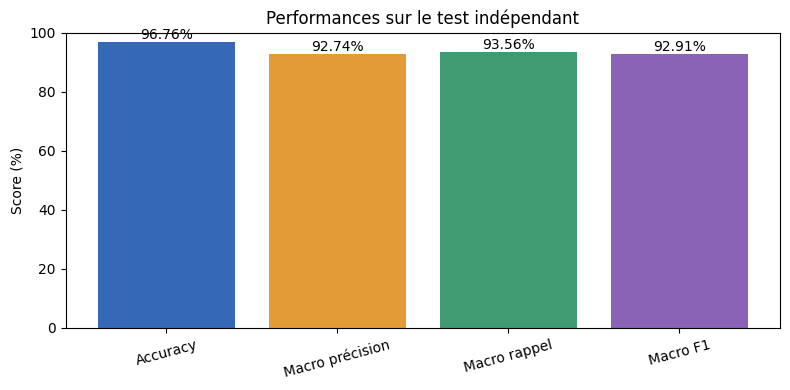

In [4]:
fig,axis=plt.subplots(figsize=(8,4))
axis.bar(results.keys(),[100*v for v in results.values()],color=['#3569b8','#e39b36','#3e9b72','#8b63b6'])
axis.set(title='Performances sur le test indépendant',ylabel='Score (%)',ylim=(0,100))
for i,v in enumerate(results.values()): axis.text(i,100*v,f'{100*v:.2f}%',ha='center',va='bottom')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## 3. Matrice de confusion

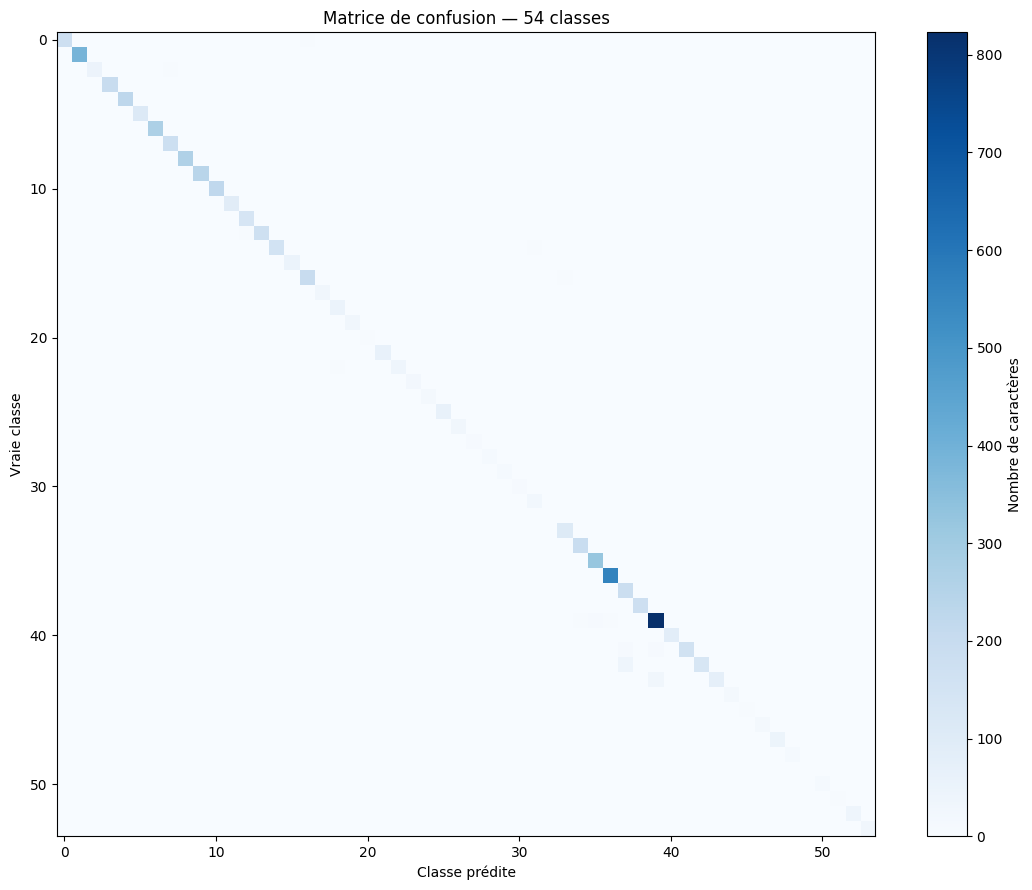

In [5]:
fig,axis=plt.subplots(figsize=(11,9))
plot=axis.imshow(confusion.numpy(),cmap='Blues',aspect='auto')
axis.set(title='Matrice de confusion — 54 classes',xlabel='Classe prédite',ylabel='Vraie classe')
fig.colorbar(plot,ax=axis,label='Nombre de caractères')
plt.tight_layout(); plt.show()

## 4. Performance par classe

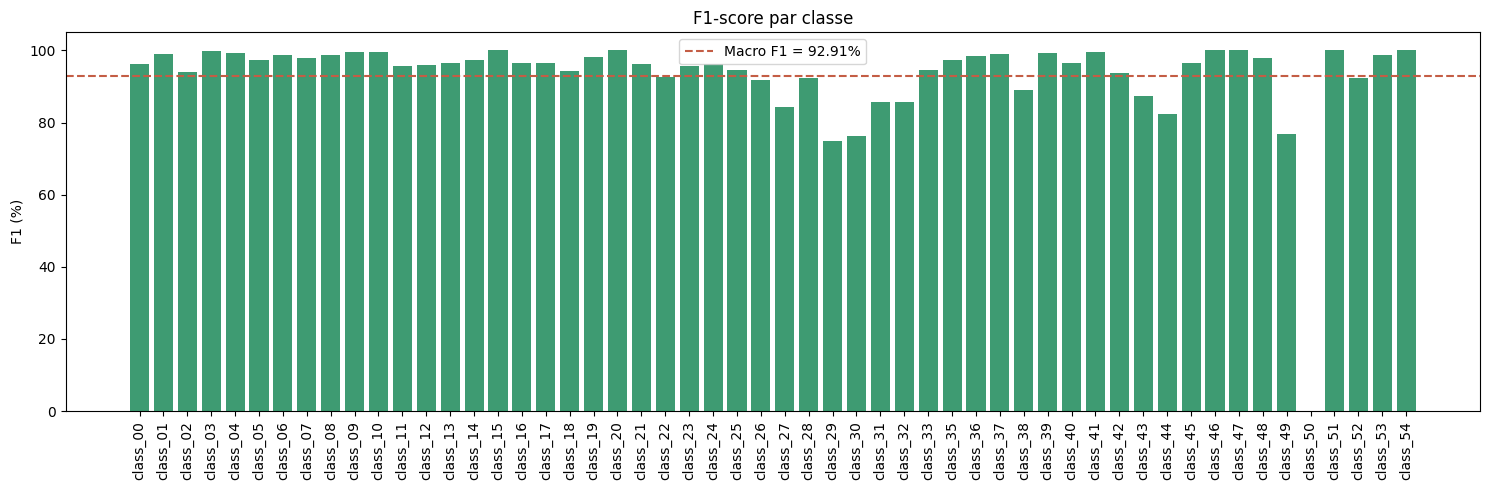

In [6]:
fig,axis=plt.subplots(figsize=(15,5))
axis.bar(data.class_names,100*f1.numpy(),color='#3e9b72')
axis.axhline(100*f1.mean(),color='#c45d45',linestyle='--',label=f'Macro F1 = {100*f1.mean():.2f}%')
axis.set(title='F1-score par classe',ylabel='F1 (%)',ylim=(0,105)); axis.tick_params(axis='x',rotation=90); axis.legend()
plt.tight_layout(); plt.show()

In [7]:
worst=sorted(range(data.num_classes),key=lambda i:float(f1[i]))[:10]
print(f"{'Classe':>10} {'Support':>8} {'Précision':>10} {'Rappel':>10} {'F1':>10}")
for i in worst:
    print(f'{data.class_names[i]:>10} {int(support[i]):>8} {precision[i]:>9.2%} {recall[i]:>9.2%} {f1[i]:>9.2%}')

    Classe  Support  Précision     Rappel         F1
  class_50        2     0.00%     0.00%     0.00%
  class_29       16    75.00%    75.00%    75.00%
  class_30       10    72.73%    80.00%    76.19%
  class_49       11    66.67%    90.91%    76.92%
  class_44      102    97.33%    71.57%    82.49%
  class_27        9    80.00%    88.89%    84.21%
  class_31       24    75.00%   100.00%    85.71%
  class_32        3    75.00%   100.00%    85.71%
  class_43      167    98.50%    78.44%    87.33%
  class_38      181    80.09%   100.00%    88.94%


## 5. Exemples corrects et erreurs

Les titres verts correspondent aux prédictions correctes, les rouges aux erreurs. La confiance seule ne garantit pas que la classe est correcte.

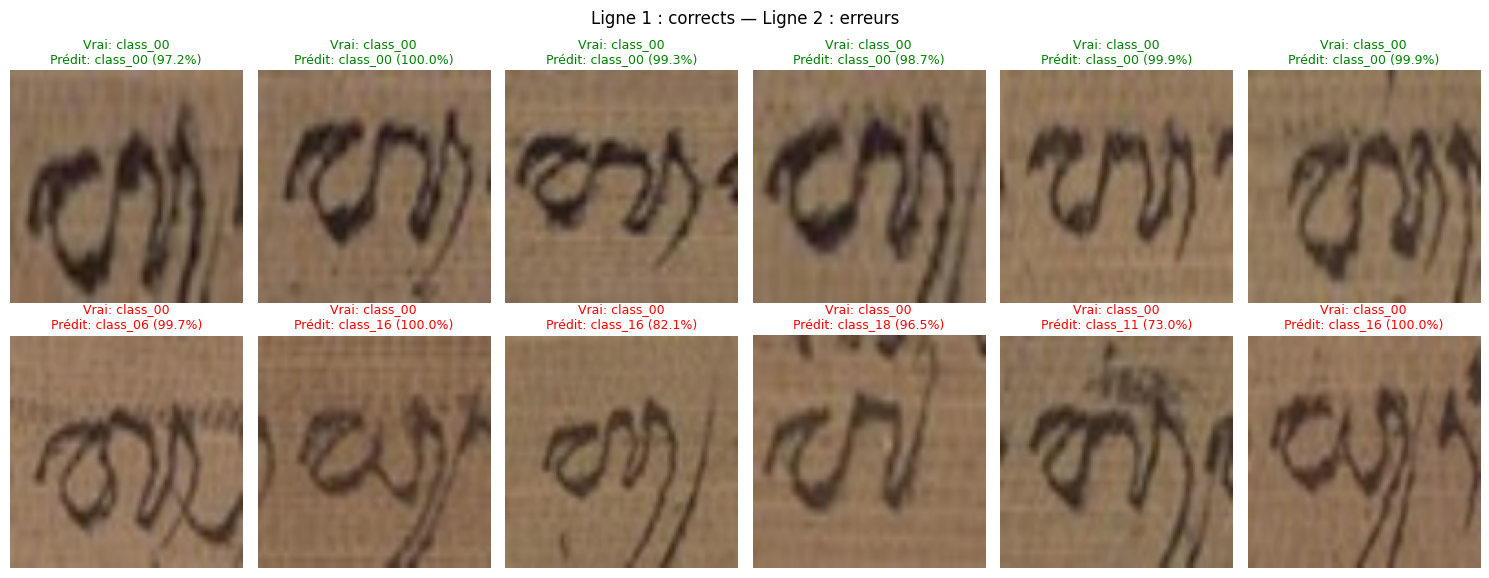

In [8]:
mean=torch.tensor([0.485,0.456,0.406]).view(3,1,1); std=torch.tensor([0.229,0.224,0.225]).view(3,1,1)
test_images,test_labels=next(iter(data.test_dataloader()))
with torch.inference_mode(): probs=model(test_images.to(device)).softmax(1).cpu()
preds=probs.argmax(1)
correct_idx=[i for i in range(len(preds)) if preds[i]==test_labels[i]][:6]
error_idx=[i for i in range(len(preds)) if preds[i]!=test_labels[i]][:6]
indices=correct_idx+error_idx
fig,axes=plt.subplots(2,6,figsize=(15,6))
for ax,i in zip(axes.ravel(),indices):
    ax.imshow((test_images[i]*std+mean).clamp(0,1).permute(1,2,0))
    ok=preds[i]==test_labels[i]
    ax.set_title(f'Vrai: {data.class_names[test_labels[i]]}\nPrédit: {data.class_names[preds[i]]} ({probs[i].max():.1%})',color='green' if ok else 'red',fontsize=9)
    ax.axis('off')
plt.suptitle('Ligne 1 : corrects — Ligne 2 : erreurs'); plt.tight_layout(); plt.show()

## 6. Tester une nouvelle image

L’image doit contenir un seul caractère, déjà découpé. La fonction retourne le top 5 avec les probabilités.

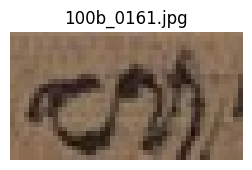

  class_00 : 97.23%
  class_16 : 2.48%
  class_06 : 0.17%
  class_40 : 0.01%
  class_41 : 0.01%


In [9]:
def predict_character(image_path,top_k=5):
    image=Image.open(image_path).convert('RGB')
    tensor=data.eval_transforms(image).unsqueeze(0).to(device)
    with torch.inference_mode(): scores=model(tensor).softmax(1)[0].cpu()
    values,indices=scores.topk(top_k)
    return image,[(data.class_names[int(i)],float(v)) for v,i in zip(values,indices)]

example_path,_=data.test_dataset.samples[0]
example,prediction_list=predict_character(example_path)
plt.figure(figsize=(3,3)); plt.imshow(example); plt.axis('off'); plt.title(Path(example_path).name); plt.show()
for name,confidence in prediction_list: print(f'{name:>10} : {confidence:.2%}')

## 7. Limites et prochaines étapes

`class_50` ne possède que deux exemples de test et reste non reconnue. Les classes rares doivent être enrichies avec de nouveaux manuscrits indépendants. Pour une translittération complète, il faudra ensuite ajouter YOLO pour la détection, l’ordre de lecture, la table classe→Unicode et les règles linguistiques balinaises.

## Conclusion

Le test indépendant confirme environ 96,76 % d’accuracy et 92,91 % de macro-F1. Le modèle est une baseline robuste pour les caractères isolés, mais pas encore un OCR de page complète.